Parameter Fitting
===

Once all the training and evaluation steps are complete, and the `config_nsbi_fit.yaml` file updated with the paths to the saved density ratios, we can perform the parameter fitting step.

We defined Signal Region (SR) and Control Region (CR) channels in the `config_nsbi_fit.yaml` file, using a preselection NN trained in `3_preselection_network.ipynb` that isolates signal-rich phase space for the NSBI analysis, with a background-rich phase space, called the CR, used for detailed validations as well as constraining background parameters. We also isolated a binned SR where the signal cross-section dominated that of the background, for a binned Poisson fit to further boost sensitivity in poorly modeled, but signal-dominant, phase space.

The objective in the NSBI SR is to build the test statistic for frequentist composite hypothesis testing:

$$t_\mu = -2 \cdot \frac{\text{Pois}(\mathcal{N}_\text{evts}|\mu, \hat{\hat{\alpha}})}{\text{Pois}(\mathcal{N}_\text{evts}|\hat{\mu}, \hat{\alpha})} -2 \cdot \sum_i^{\mathcal{N}_\text{evts}} w_i \times \log \frac{p(x_i|\mu, \hat{\hat{\alpha}})}{p(x_i|\hat{\mu}, \hat{\alpha})} + \sum_p^{N_\text{systs}} \hat{\hat{\alpha}}_p^2 - \hat{\alpha}_p^2$$

As mentioned in the previous notebooks, we rewrite the test statistic to turn this into a density ratio estimation task:

$$t_\mu = -2 \cdot \frac{\text{Pois}(\mathcal{N}_\text{evts}|\mu, \hat{\hat{\alpha}})}{\text{Pois}(\mathcal{N}_\text{evts}|\hat{\mu}, \hat{\alpha})} -2 \cdot \sum_i^{\mathcal{N}_\text{evts}} w_i \times \log \frac{p(x_i|\mu, \hat{\hat{\alpha}})/p_{ref}(x)}{p(x_i|\hat{\mu}, \hat{\alpha})/p_{ref}(x)} + \sum_p^{N_\text{systs}} \hat{\hat{\alpha}}_p^2 - \hat{\alpha}_p^2$$


## Building the model

In the `4_nerual_likelihood_ratio_estimation.ipynb` and `5_systematic_uncertainty_training.ipynb` notebook, we trained neural networks to estimate the relevant density ratios needed to build our full statistical model. In this notebook, we evaluate density ratios using those trained models for the Asimov dataset. 

The full model is written as

$$\frac{p(x|\mu, \alpha)}{p_{ref}(x)} = \frac{1}{\sum_c G_c(\alpha) \cdot f_c(\mu) \cdot \nu_c} \sum_c f_c(\mu) \cdot G_c(\alpha)\cdot \nu_c \cdot g_c(x|\alpha) \cdot \underbrace{\frac{p_c\left(x\right)}{p_{ref}(x)}}_{NN}$$
where,
$$g_c(x|\alpha) = \frac{p_c(x|\alpha)}{p_\text{c}(x)} = \prod_p \frac{p_c(x|\alpha_p)}{p_\text{c}(x)}$$

and we used a HistFactory-style interpolation generalized to a per-event formulation:

$$\frac{p_c(x|\alpha_p^{eval})}{p_\text{c}(x)} = \begin{cases}
    \bigg(\underbrace{\frac{p_c(x|\alpha_p^+)}{p_\text{c}(x)}}_{NN}\bigg)^{\alpha_p^\text{eval}}& \alpha_p^\text{eval}>1\\
    1+\sum_{n=1}^6c_n\cdot (\alpha_p^\text{eval})^n& -1\leq\alpha_p^\text{eval}\leq 1\\
    \bigg(\underbrace{\frac{p_c(x|\alpha_p^-)}{p_\text{c}(x)}}_{NN}\bigg)^{-\alpha_p^\text{eval}}& \alpha_p^\text{eval}<-1\\
    \end{cases}$$


 In this notebook, we build a statistical model using these trained density ratios that are evaluated on the Asimov dataset in `6_evaluate_networks.ipynb` notebook.

In [1]:
import os, sys
import pprint
import argparse
import logging
import warnings
import matplotlib.pyplot as plt
import mplhep as hep
import yaml
import jax

import nsbi_common_utils

jax.config.update("jax_enable_x64", True)

# Set Style
hep.style.use(hep.style.ATLAS)

In [2]:
def load_config(path):
    with open(path, "r") as f:
        return yaml.safe_load(f)

In [3]:
config_workflow = load_config("./config.pipeline.yaml")["parameter_fitting"]
    
plots_dir = config_workflow["output"]["plots_dir"]

In [4]:
print("Starting Inference")
print(f"Configurations: Histogram fit = {config_workflow['configs']['histogram']}, NSBI fit = {config_workflow['configs']['nsbi']}")

Starting Inference
Configurations: Histogram fit = ./config_fit_histogram.yml, NSBI fit = ./config_fit_nsbi.yml


In [5]:
measurement = config_workflow["measurement"]
print(f"Performing a fit for the measurement {measurement} defined in the fit configuration file")

# scan_param = config_workflow["scan"]["parameter"]
# scan_range = tuple(config_workflow["scan"]["range"])
# scan_steps = config_workflow["scan"]["steps"]

Performing a fit for the measurement higgs_tautau_signal_strength defined in the fit configuration file


Building a Workspace
--

Now it is time to write the statistical model into a serialized specification file, referred to as a `workspace` in `pyhf` and `HistFactory` jargon. It can be built from the config file using the `nsbi_common_utils.workspace_builder` class, but also can be provided standalone, following the specific schema defined here.

In [6]:
hist_config_path = config_workflow["configs"]["histogram"]
ws_hist = nsbi_common_utils.workspace_builder.WorkspaceBuilder(config_path=hist_config_path).build()

In [7]:
nsbi_config_path = config_workflow["configs"]["nsbi"]
ws_nsbi = nsbi_common_utils.workspace_builder.WorkspaceBuilder(config_path=nsbi_config_path).build()

The Model
-

Now lets take a look at how this workspace looks like. It is almost identical to the `pyhf` workspace schema, except it allows for analysis regions with NSBI-type fits. 

In [8]:
print(f"The NSBI fit workspace is \n\n")
pprint.pprint(ws_nsbi)

The NSBI fit workspace is 


{'channels': [{'name': 'CR',
               'samples': [{'data': [319.97644, 62478.27, 616146.44],
                            'modifiers': [{'data': None,
                                           'name': 'mu_ztautau',
                                           'type': 'normfactor'},
                                          {'data': {'hi_data': [1.0086704,
                                                                0.9953745,
                                                                0.9993026],
                                                    'lo_data': [0.9999999,
                                                                1.0043222,
                                                                1.000726]},
                                           'name': 'JES',
                                           'type': 'normplusshape'},
                                          {'data': {'hi_data': [0.998555,
                               

The `nsbi_common_utils.models.sbi_parametric_model` can take as input this serialized workspace and build a likelihood model in JAX, with just-in-time (JIT) compilation. 

In [9]:
# model.Model returns the negative log-likelihood 
model_hist = nsbi_common_utils.models.sbi_parametric_model(workspace=ws_hist, 
                                                            measurement_to_fit=measurement)
        
model_nsbi = nsbi_common_utils.models.sbi_parametric_model(workspace=ws_nsbi, 
                                                            measurement_to_fit=measurement)

Loaded ratio data for sample 'ztautau' in channel 'SR': shape (2772426,)
Loaded ratio data for sample 'ttbar' in channel 'SR': shape (2772426,)
Loaded ratio data for sample 'htautau' in channel 'SR': shape (2772426,)


In [10]:
list_params, init_values = model_hist.get_model_parameters()
num_unconstrained = model_hist.num_unconstrained_param

Having processed all the inputs needed, we pass the likelihood model `nsbi_common_utils.models.sbi_parametric_model` that builds

$$\text{NLL} = -2 \cdot \log \text{Pois}(\mathcal{N}_\text{evts}|\mu, \alpha) - 2\log \frac{p(x|\mu, \alpha)}{p_{ref}(x)} + \sum_p^{N_\text{systs}} \alpha_p^2 $$

with

$$\frac{p(x|\mu, \alpha)}{p_{ref}(x)} = \frac{1}{\sum_c G_c(\alpha) \cdot f_c(\mu) \cdot \nu_c} \sum_c f_c(\mu) \cdot G_c(\alpha) \cdot \nu_c \cdot g_c(x|\alpha) \cdot \frac{p_c\left(x\right)}{p_{ref}(x)}$$

to the `inference` class of `nsbi_common_utils/inference.py` for fitting. The fitting step uses `iminuit` to minimize the NLL and build the profile negative log-likelihood test statistic:

$$t_\mu = -2 \cdot \frac{\text{Pois}(\mathcal{N}_\text{evts}|\mu, \hat{\hat{\alpha}})}{\text{Pois}(\mathcal{N}_\text{evts}|\hat{\mu}, \hat{\alpha})} -2 \cdot \sum_i^{\mathcal{N}_\text{evts}} w_i \times \log \frac{p(x_i|\mu, \hat{\hat{\alpha}})/p_{ref}(x)}{p(x_i|\hat{\mu}, \hat{\alpha})/p_{ref}(x)} + \sum_p^{N_\text{systs}} \hat{\hat{\alpha}}_p^2 - \hat{\alpha}_p^2$$



In [11]:
inf_hist = nsbi_common_utils.inference.inference(
            model_nll=model_hist.model,
            initial_values=init_values,
            list_parameters=list_params,
            num_unconstrained_params=num_unconstrained
        )

inf_nsbi = nsbi_common_utils.inference.inference(
            model_nll=model_nsbi.model,
            initial_values=init_values,
            list_parameters=list_params,
            num_unconstrained_params=num_unconstrained
        )

In [12]:
freeze_params = []

In [13]:
print("\n" + "="*40)
print(" NSBI FIT RESULTS ")
print("="*40 + "\n")
inf_nsbi.perform_fit(freeze_params=freeze_params)


 NSBI FIT RESULTS 

fit: 
 ┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = -2.63e+07                  │              Nfcn = 158              │
│ EDM = 0.000129 (Goal: 0.0002)    │           time = 67.8 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬────────────┬───────────┬───────────┬────────────┬─────

In [14]:
print("\n" + "="*40)
print(" HISTOGRAM FIT RESULTS ")
print("="*40 + "\n")
inf_hist.perform_fit(freeze_params=freeze_params)


 HISTOGRAM FIT RESULTS 

fit: 
 ┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = -2.378e+07                 │              Nfcn = 122              │
│ EDM = 2.35e-07 (Goal: 0.0002)    │            time = 0.4 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬────────────┬───────────┬───────────┬────────────┬

In [15]:
scan_points_hist, NLL_value_hist, scan_points_StatOnly_hist, NLL_value_StatOnly_hist = inf_hist.perform_profile_scan(parameter_name = 'mu_htautau', 
                             freeze_params = freeze_params, 
                             bound_range = (0.0, 3.0), 
                             fit_strategy = 0, 
                             doStatOnly = True,
                             size = 50)

In [16]:
scan_points_nsbi, NLL_value_nsbi, scan_points_StatOnly_nsbi, NLL_value_StatOnly_nsbi = inf_nsbi.perform_profile_scan(parameter_name = 'mu_htautau', 
                             freeze_params = freeze_params, 
                             bound_range = (0.0, 3.0), 
                             fit_strategy = 0, 
                             doStatOnly = True,
                             size = 50)

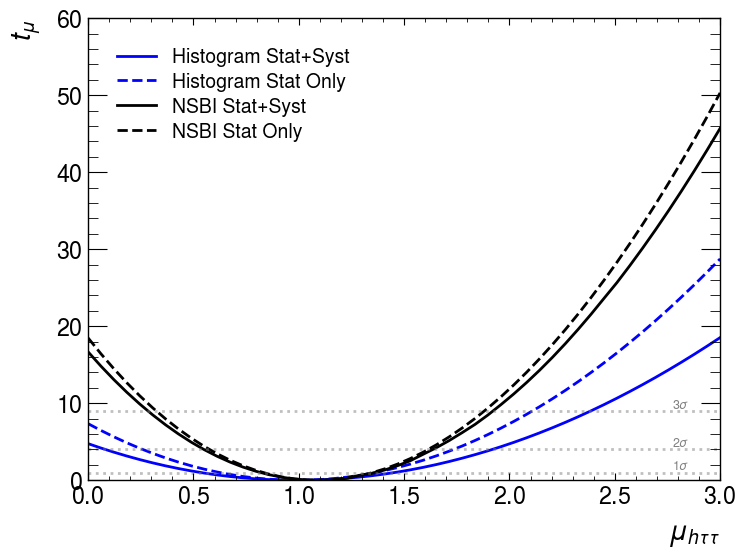

In [17]:
parameter_label = r'$\mu_{h\tau\tau}$'
list_scan_points = [scan_points_hist, scan_points_StatOnly_hist, scan_points_nsbi, scan_points_StatOnly_nsbi]
list_nll_values = [NLL_value_hist, NLL_value_StatOnly_hist, NLL_value_nsbi, NLL_value_StatOnly_nsbi]
list_labels = ["Histogram Stat+Syst", "Histogram Stat Only", "NSBI Stat+Syst", "NSBI Stat Only"]
list_linestyles = ["-", "--", "-", "--"]
list_colors = ["blue", "blue", "black", "black"]

nsbi_common_utils.inference.plot_NLL_scans(parameter_label, list_scan_points, list_nll_values, list_labels, list_linestyles, list_colors)

Optimizing the analysis
===

**As we increase the number of parameters, the robustness of the density ratio modelling becomes more important. Building ensembles and optimizing preselections are important. Each of the $O(100)$ nuisance paramters typical in an LHC analysis needs to be checked for bias.**

Things that can be optimized for better convergence:

- Generate more simulated events for better modelling.
- Tighter preselections - removing more of the background-rich phase space $p_{ref}\sim 0$ that can cause numerical instabilites, removing phase space regions with low Monte Carlo statistics or that are difficult to model, etc.
- Add more input features for easier signal-background separation.
- Changing the hyperparameters of the various NNs used in the modelling.
- Training ensembles of NNs
